In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
Cdo_aircraft = 0.02873
AR = 7.53
S_ref = 0.5307
e = 0.8
K = 1 / (np.pi * AR * e)
Mass_aircraft = 6.5
Weight_aircraft = Mass_aircraft * 9.81
rho = 1.142

def calculate_Cd(Cdo, K, Cl):
    return Cdo + K * Cl**2

def calculate_Cl(W, rho, V, S):
    return (2 * W) / (rho * V**2 * S)

Power_avalable = 450 # Estimated celing in Watts
Battery_energy = 12*22.2*3600 # Battery energy in Joules (12000 mAh at 22.2 V)
eta_prop = 0.7 # Propeller efficiency
eta_motor = 0.85 # Motor efficiency

print(f"Battery energy in Joules: {Battery_energy:.2f} J")

Battery energy in Joules: 959040.00 J


In [28]:
L_d_max_Ac = 1 / (2 * np.sqrt(Cdo_aircraft * K))
print(f"Maximum L/D for the aircraft: {L_d_max_Ac:.4f}")

Maximum L/D for the aircraft: 12.8327


In [29]:
V_max_range = (2*Weight_aircraft / (rho * S_ref) * (np.sqrt(K/Cdo_aircraft)))**0.5
print(f"Velocity for maximum range: {V_max_range:.2f} m/s")

V_max_endurance = (2*Weight_aircraft / (rho * S_ref) * (np.sqrt(K/(3*Cdo_aircraft))))**0.5
print(f"Velocity for maximum endurance: {V_max_endurance:.2f} m/s")

Power_required_max_range = rho * S_ref * V_max_range**3 * Cdo_aircraft 
Power_required_max_endurance = 2*rho * S_ref * V_max_endurance**3 * Cdo_aircraft
print(f"Power required for maximum range: {Power_required_max_range:.2f} W")
print(f"Power required for maximum endurance: {Power_required_max_endurance:.2f} W")

Range_max = (eta_prop * eta_motor * Battery_energy*V_max_endurance) / Power_required_max_range
Endurance_max = (eta_prop * eta_motor * Battery_energy) / Power_required_max_endurance
print(f"Maximum range: {Range_max/1000:.2f} km")
print(f"Maximum endurance: {Endurance_max/3600:.2f} hours")

Velocity for maximum range: 16.89 m/s
Velocity for maximum endurance: 12.84 m/s
Power required for maximum range: 83.94 W
Power required for maximum endurance: 73.65 W
Maximum range: 87.26 km
Maximum endurance: 2.15 hours


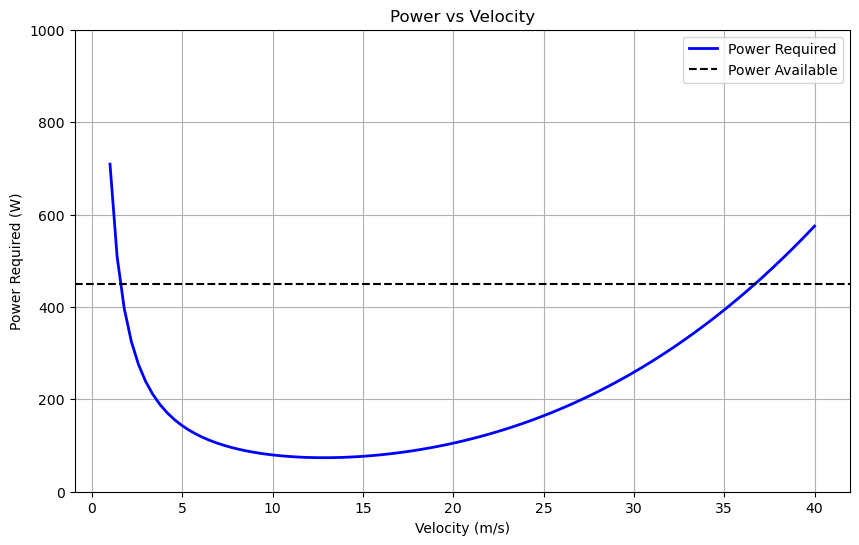

<Figure size 640x480 with 0 Axes>

In [34]:
v_arr = np.linspace(1, 40, 100)
C_l_arr = calculate_Cl(Weight_aircraft, rho, v_arr, S_ref)
C_d_arr = calculate_Cd(Cdo_aircraft, K, C_l_arr)
P_req = rho * S_ref * v_arr**3 * C_d_arr / 2  

plt.figure(figsize=(10, 6))
plt.plot(v_arr, P_req, "b-", linewidth=2, label="Power Required")
plt.axhline(Power_avalable, color="k", linestyle="--", label="Power Available")
plt.title("Power vs Velocity")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Power Required (W)")
plt.ylim(0, 1000)
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("Power_vs_Velocity.png", dpi=300)


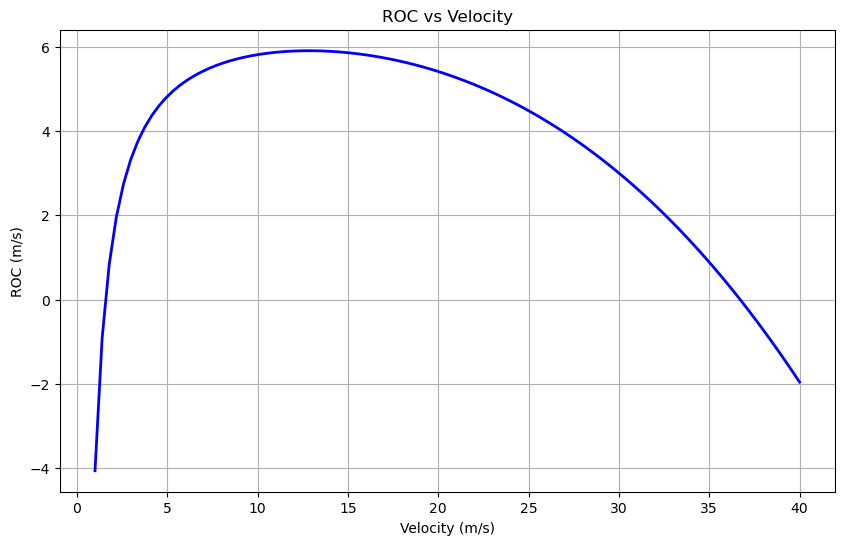

<Figure size 640x480 with 0 Axes>

In [39]:
ROC = (Power_avalable - P_req) / Weight_aircraft

plt.figure(figsize=(10, 6))
plt.plot(v_arr, ROC, "b-", linewidth=2)
plt.title("ROC vs Velocity")
plt.xlabel("Velocity (m/s)")
plt.ylabel("ROC (m/s)")
#plt.ylim(0, 10)
plt.grid(True)
plt.show()
plt.savefig("ROC_vs_Velocity.png")